Dataset Analysis Summary:
           Class  Count  Percentage
    MildDemented    896        14.0
ModerateDemented     64         1.0
     NonDemented   3200        50.0
VeryMildDemented   2240        35.0


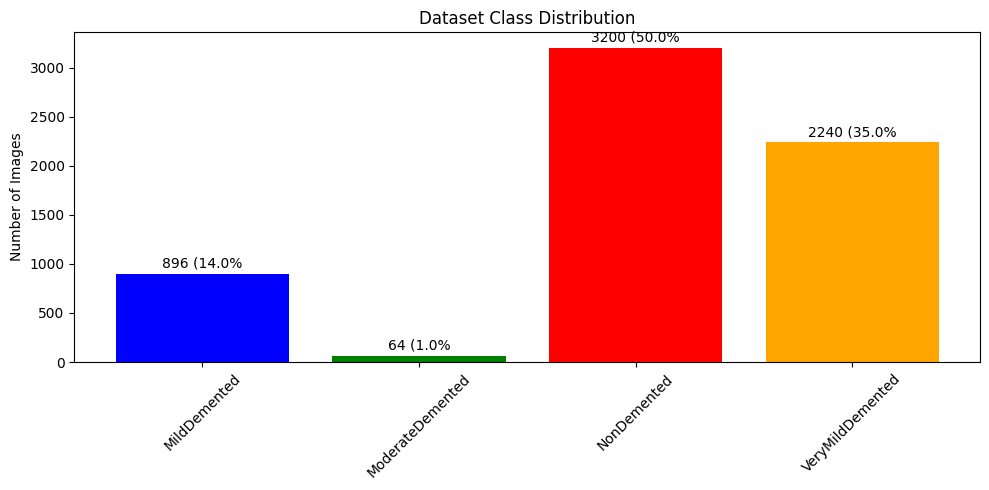

In [7]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

def analyze_alzheimer_original_dataset(dataset_path):
    """
    Performs basic data analysis on the Original Alzheimer MRI Dataset.
    
    This function counts the number of images in each class,
    computes class distributions, and visualizes the results with a bar chart.
    Note: Assumes no explicit train/test splits; treats the entire dataset as one.

    Args:
    dataset_path (str): Path to the root directory of the dataset (e.g., '/kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset').
    
    Returns:
    pd.DataFrame: A DataFrame with counts and percentages for each class.
    """
    # Define classes
    classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
    
    # Dictionary to hold counts
    counts = defaultdict(int)
    total_count = 0
    
    # Traverse the directory structure
    for cls in classes:
        class_path = os.path.join(dataset_path, cls)
        if os.path.exists(class_path):
            num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
            counts[cls] = num_images
            total_count += num_images
        else:
            print(f"Warning: {class_path} not found.")
    
    # Create DataFrame for results
    data = []
    for cls in classes:
        count = counts[cls]
        percentage = (count / total_count * 100) if total_count > 0 else 0
        data.append({
            'Class': cls,
            'Count': count,
            'Percentage': round(percentage, 2)
        })
    
    df = pd.DataFrame(data)
    print("Dataset Analysis Summary:")
    print(df.to_string(index=False))
    
    # Visualize class distribution
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    
    # Dataset distribution
    class_counts = [counts[cls] for cls in classes]
    colors = ['blue', 'green', 'red', 'orange']
    ax.bar(classes, class_counts, color=colors)
    ax.set_title('Dataset Class Distribution')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=45)
    
    # Add percentage labels on bars
    for i, v in enumerate(class_counts):
        ax.text(i, v + max(class_counts)*0.01, f'{v} ({data[i]["Percentage"]}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return df

df_analysis = analyze_alzheimer_original_dataset('/kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset')

Dataset Analysis Summary:
           Class  Count  Percentage
    MildDemented   8960       26.37
ModerateDemented   6464       19.02
     NonDemented   9600       28.25
VeryMildDemented   8960       26.37


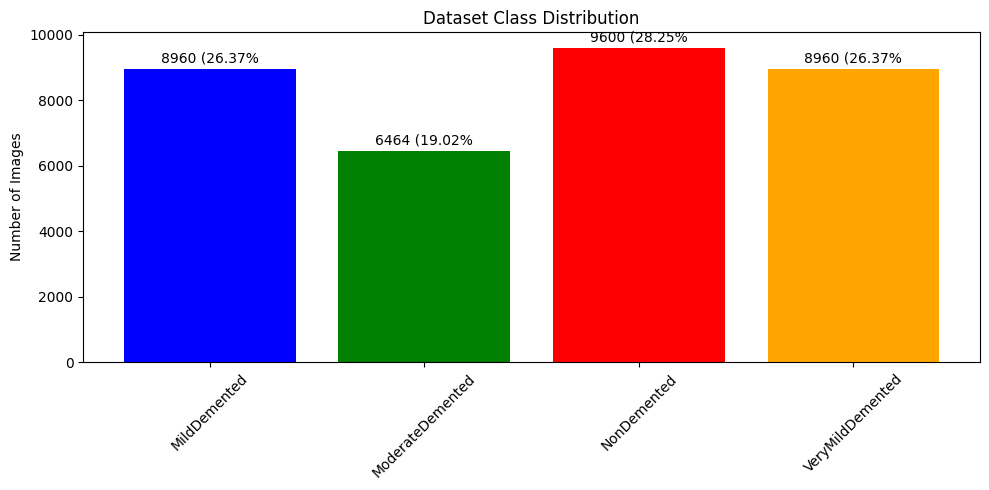

In [8]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

def analyze_alzheimer_original_dataset(dataset_path):
    """
    Performs basic data analysis on the Original Alzheimer MRI Dataset.
    
    This function counts the number of images in each class,
    computes class distributions, and visualizes the results with a bar chart.
    Note: Assumes no explicit train/test splits; treats the entire dataset as one.

    Args:
    dataset_path (str): Path to the root directory of the dataset (e.g., '/kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset').
    
    Returns:
    pd.DataFrame: A DataFrame with counts and percentages for each class.
    """
    # Define classes
    classes = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
    
    # Dictionary to hold counts
    counts = defaultdict(int)
    total_count = 0
    
    # Traverse the directory structure
    for cls in classes:
        class_path = os.path.join(dataset_path, cls)
        if os.path.exists(class_path):
            num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
            counts[cls] = num_images
            total_count += num_images
        else:
            print(f"Warning: {class_path} not found.")
    
    # Create DataFrame for results
    data = []
    for cls in classes:
        count = counts[cls]
        percentage = (count / total_count * 100) if total_count > 0 else 0
        data.append({
            'Class': cls,
            'Count': count,
            'Percentage': round(percentage, 2)
        })
    
    df = pd.DataFrame(data)
    print("Dataset Analysis Summary:")
    print(df.to_string(index=False))
    
    # Visualize class distribution
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    
    # Dataset distribution
    class_counts = [counts[cls] for cls in classes]
    colors = ['blue', 'green', 'red', 'orange']
    ax.bar(classes, class_counts, color=colors)
    ax.set_title('Dataset Class Distribution')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=45)
    
    # Add percentage labels on bars
    for i, v in enumerate(class_counts):
        ax.text(i, v + max(class_counts)*0.01, f'{v} ({data[i]["Percentage"]}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return df

df_analysis = analyze_alzheimer_original_dataset('/kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset')

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
from torch.optim.lr_scheduler import CosineAnnealingLR
print("Setup complete. Device:", torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

Setup complete. Device: cuda


In [10]:
class VisualEncoder(nn.Module):
    def __init__(self, out_dim=256, grid_size=7):
        super().__init__()
        # Simple CNN backbone for ultrasound frames (lightweight for videos)
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, out_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.grid_size = grid_size  # N = grid_size^2 nodes per frame

    def forward(self, frames):
        # frames: B, T, C, H, W
        B, T, C, H, W = frames.shape
        frames_flat = frames.view(B * T, C, H, W)
        feats = self.cnn(frames_flat)  # B*T, d, h', w'
        # Pool to grid for patches/nodes
        g = self.grid_size
        feats = F.adaptive_avg_pool2d(feats, (g, g))
        N = g * g
        d = feats.size(1)
        # Reshape to patches: average per grid cell
        patches = feats.permute(0, 2, 3, 1).reshape(B * T, N, d)
        return patches.view(B, T, N, d)

# Test
encoder = VisualEncoder()
dummy_frames = torch.randn(2, 8, 3, 224, 224)
out = encoder(dummy_frames)
print(f"Node features shape: {out.shape}")  # Expected: (2, 8, 49, 256)

Node features shape: torch.Size([2, 8, 49, 256])


In [11]:
class EdgeGRU(nn.Module):
    def __init__(self, edge_dim=64):
        super().__init__()
        self.gru = nn.GRUCell(edge_dim, edge_dim)

    def forward(self, e_prev, edge_msg):
        # edge_msg: B, E, edge_dim
        B, E, _ = edge_msg.shape
        if e_prev is None:
            h = torch.zeros(B, E, self.gru.hidden_size, device=edge_msg.device)
        else:
            h = e_prev
        # GRUCell expects (batch*seq, input_size), but since cell, flatten
        input_flat = edge_msg.view(-1, self.gru.input_size)
        h_flat = h.view(-1, self.gru.hidden_size)
        out_flat = self.gru(input_flat, h_flat)
        return out_flat.view(B, E, -1)

# Test
edge_gru = EdgeGRU()
dummy_msg = torch.randn(2, 100, 64)  # B=2, E=100
out = edge_gru(None, dummy_msg)
print(f"Edge state shape: {out.shape}")

Edge state shape: torch.Size([2, 100, 64])


In [12]:
class DST_HGNN(nn.Module):
    def __init__(self, node_dim=256, num_rel=4, num_classes=4, N=49, T_max=32, edge_dim=64):
        super().__init__()
        self.encoder = VisualEncoder(out_dim=node_dim)
        self.N = N
        self.T_max = T_max
        self.num_rel = num_rel
        
        # Relation-specific transforms
        self.relation_transforms = nn.ModuleList([nn.Linear(node_dim, node_dim) for _ in range(num_rel)])
        
        # Node update GRU
        self.node_gru = nn.GRUCell(node_dim, node_dim)
        
        # Edge projection and GRU
        self.edge_proj = nn.Linear(4 * node_dim, edge_dim)
        self.edge_gru = EdgeGRU(edge_dim)
        
        # Temporal attention (simple linear for pooling)
        self.temp_att = nn.Linear(node_dim, 1)
        
        # Node attention for graph pooling
        self.node_att = nn.Linear(node_dim, 1)
        
        # Affinity MLP for spatial edges
        self.affinity_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + 1, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
        # Gate MLP for edge modulation
        self.gate_mlp = nn.Linear(edge_dim, 1)
        
        # Readout
        self.readout_mlp = nn.Sequential(
            nn.Linear(node_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def build_edges(self, x_t, h_prev, device):
        B, N, d = x_t.shape
        # Grid positions for distance
        g = int(np.sqrt(N))
        idx = torch.arange(g, device=device)
        yy, xx = torch.meshgrid(idx, idx, indexing='ij')
        positions = torch.stack([xx, yy], dim=-1).float().reshape(N, 2)
        positions = positions.unsqueeze(0).expand(B, -1, -1)
        dist = torch.cdist(positions, positions)  # B, N, N
        
        # Affinity scores
        x_i = x_t.unsqueeze(2).expand(-1, -1, N, -1)
        x_j = x_t.unsqueeze(1).expand(-1, N, -1, -1)
        concat_aff = torch.cat([x_i, x_j, dist.unsqueeze(-1)], dim=-1).view(B, N * N, -1)
        aff = self.affinity_mlp(concat_aff).squeeze(-1).view(B, N, N)
        w_spatial = torch.sigmoid(aff) * (dist < 0.3).float()  # Local edges
        
        # Edge features for GRU
        cat_edge = torch.cat([h_prev.unsqueeze(2), h_prev.unsqueeze(1), x_t.unsqueeze(2), x_t.unsqueeze(1)], dim=-1).view(B, N * N, 4 * d)
        edge_feats = self.edge_proj(cat_edge)
        
        # Temporal edges (identity for simplicity)
        w_temporal = torch.eye(N, device=device).unsqueeze(0).expand(B, -1, -1)
        
        return w_spatial, edge_feats, w_temporal

    def forward(self, frames):
        B, T, C, H, W = frames.shape
        X = self.encoder(frames)  # B, T, N, d
        h = torch.zeros(B, self.N, X.size(-1), device=frames.device)
        e_state = None
        h_history = []
        
        for t in range(T):
            x_t = X[:, t]
            w_spatial, edge_feats, w_temporal = self.build_edges(x_t, h, frames.device)
            e_state = self.edge_gru(e_state, edge_feats)
            
            # Edge gating
            gate = torch.sigmoid(self.gate_mlp(e_state))  # B, E, 1
            edge_feats_gated = edge_feats * gate
            
            # Message passing (simplified to spatial relation 0)
            W_r = self.relation_transforms[0]
            h_transformed = W_r(h)
            # Aggregate messages
            msgs = torch.bmm(w_spatial, h_transformed)
            
            # Node update
            h_flat = h.view(-1, X.size(-1))
            msgs_flat = msgs.view(-1, X.size(-1))
            h = self.node_gru(msgs_flat, h_flat).view(B, self.N, -1)
            h_history.append(h)
        
        # Temporal readout
        H_time = torch.stack(h_history, dim=2)  # B, N, T, d
        att_weights = F.softmax(self.temp_att(H_time), dim=2)  # B, N, T, 1
        s = torch.sum(att_weights * H_time, dim=2)  # B, N, d (temporal pooled nodes)
        
        # Graph pooling
        u = torch.sigmoid(self.node_att(s).squeeze(-1))  # B, N
        G_repr = torch.sum(u.unsqueeze(-1) * s, dim=1)  # B, d
        logits = self.readout_mlp(G_repr)
        
        # Explainability
        expl = {
            'node_att': u,  # Spatial importance
            'temp_att': att_weights.mean(dim=1),  # Avg frame importance per node
        }
        return logits, expl

# Test
model = DST_HGNN(num_classes=4)
dummy_frames = torch.randn(2, 8, 3, 224, 224)
logits, expl = model(dummy_frames)
print(f"Logits shape: {logits.shape}")
print(f"Expl keys: {expl.keys()}")

RuntimeError: Sizes of tensors must match except in dimension 3. Expected size 49 but got size 1 for tensor number 1 in the list.